# Deep Convolutional Neural Network-Based Object Detection for Video Forgery Identification

This notebook implements an end-to-end **video forgery identification** pipeline with a deep CNN detector.

It covers:
1. Environment setup and reproducibility
2. Data paths and experiment configuration
3. Frame extraction from videos
4. Annotation preparation and validation
5. Video-level data splits
6. Custom PyTorch Dataset/DataLoader
7. Spatial and temporal augmentation
8. Detection model initialization
9. Optimizer and scheduler setup
10. Mixed precision training loop
11. Validation metrics (mAP/precision/recall)
12. Temporal post-processing for forgery flags
13. Checkpointing and logging
14. Test evaluation and prediction export
15. Detection visualization and failure-case review

In [1]:
# Section 1: Set Up Environment and Dependencies
# Run this cell once per environment.
%pip install -q torch torchvision torchaudio opencv-python albumentations numpy pandas matplotlib scikit-learn tqdm torchmetrics seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Section 1 (continued): Imports and reproducibility
import json
import random
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

import albumentations as A
from albumentations.pytorch import ToTensorV2

from torchmetrics.detection.mean_ap import MeanAveragePrecision

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_DEVICE = 'cuda' if DEVICE.type == 'cuda' else 'cpu'
print('Using device:', DEVICE)

c:\Users\pujit\OneDrive\Desktop\major project\sudha\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [15]:
# Section 2: Load Project Files and Configure Paths
PROJECT_ROOT = Path.cwd()
RAW_REAL_DIR = PROJECT_ROOT / 'videos_real'
RAW_FAKE_DIR = PROJECT_ROOT / 'videos_fake'

WORK_DIR = PROJECT_ROOT / 'artifacts'
FRAMES_DIR = WORK_DIR / 'extracted_frames'
MANIFEST_DIR = WORK_DIR / 'manifests'
CHECKPOINT_DIR = WORK_DIR / 'checkpoints'
LOG_DIR = WORK_DIR / 'logs'
OUTPUT_DIR = WORK_DIR / 'outputs'
ANNOTATIONS_DIR = PROJECT_ROOT / 'annotations'  # optional (YOLO txt or COCO json)

for d in [WORK_DIR, FRAMES_DIR, MANIFEST_DIR, CHECKPOINT_DIR, LOG_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CONFIG = {
    'img_size': 512,
    'batch_size': 4,
    'num_workers': 0,
    'epochs': 8,
    'lr': 3e-4,
    'weight_decay': 1e-4,
    'max_grad_norm': 5.0,
    'frames_per_video': 12,
    'train_ratio': 0.7,
    'val_ratio': 0.15,
    'test_ratio': 0.15,
    'confidence_threshold': 0.4,
    'temporal_smoothing_window': 5,
    'temporal_forgery_threshold': 0.45,
    'checkpoint_every': 1,
    'cpu_max_train_frames': 32,
    'cpu_max_val_frames': 16,
    'cpu_max_test_frames': 16,
}

# Auto lightweight mode for CPU training
if DEVICE.type == 'cpu':
    CONFIG['epochs'] = 1
    CONFIG['batch_size'] = 2

assert abs(CONFIG['train_ratio'] + CONFIG['val_ratio'] + CONFIG['test_ratio'] - 1.0) < 1e-8

VIDEO_EXTENSIONS = {'.mp4', '.avi', '.mov', '.mkv'}

print('Project root:', PROJECT_ROOT)
print('Real videos dir exists:', RAW_REAL_DIR.exists())
print('Fake videos dir exists:', RAW_FAKE_DIR.exists())
print('Config:', CONFIG)

Project root: c:\Users\pujit\OneDrive\Desktop\major project\sudha\SDFVD\SDFVD
Real videos dir exists: True
Fake videos dir exists: True
Config: {'img_size': 512, 'batch_size': 2, 'num_workers': 0, 'epochs': 1, 'lr': 0.0003, 'weight_decay': 0.0001, 'max_grad_norm': 5.0, 'frames_per_video': 12, 'train_ratio': 0.7, 'val_ratio': 0.15, 'test_ratio': 0.15, 'confidence_threshold': 0.4, 'temporal_smoothing_window': 5, 'temporal_forgery_threshold': 0.45, 'checkpoint_every': 1, 'cpu_max_train_frames': 32, 'cpu_max_val_frames': 16, 'cpu_max_test_frames': 16}


In [3]:
# Section 3 + 5: Index videos and create reproducible video-level splits

def list_videos(folder: Path, label_name: str):
    videos = []
    if not folder.exists():
        return videos
    for p in sorted(folder.iterdir()):
        if p.suffix.lower() in VIDEO_EXTENSIONS:
            videos.append({'video_path': str(p), 'label_name': label_name})
    return videos

videos = list_videos(RAW_REAL_DIR, 'real') + list_videos(RAW_FAKE_DIR, 'fake')
video_df = pd.DataFrame(videos)

if video_df.empty:
    raise RuntimeError('No videos found. Check videos_real and videos_fake folders.')

video_df['video_id'] = video_df['video_path'].apply(lambda x: Path(x).stem)
video_df['label'] = (video_df['label_name'] == 'fake').astype(int)

train_df, temp_df = train_test_split(
    video_df,
    test_size=(1.0 - CONFIG['train_ratio']),
    random_state=SEED,
    stratify=video_df['label']
)

val_size_adjusted = CONFIG['val_ratio'] / (CONFIG['val_ratio'] + CONFIG['test_ratio'])
val_df, test_df = train_test_split(
    temp_df,
    test_size=(1.0 - val_size_adjusted),
    random_state=SEED,
    stratify=temp_df['label']
)

train_df = train_df.copy(); train_df['split'] = 'train'
val_df = val_df.copy(); val_df['split'] = 'val'
test_df = test_df.copy(); test_df['split'] = 'test'

video_splits_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
video_splits_df.to_csv(MANIFEST_DIR / 'video_splits.csv', index=False)

print(video_splits_df.groupby(['split', 'label_name']).size().unstack(fill_value=0))

label_name  fake  real
split                 
test           8     8
train         37    37
val            8     8


In [4]:
# Section 3: Extract Frames from Videos and store metadata

def sample_frame_indices(total_frames: int, n_samples: int):
    if total_frames <= 0:
        return []
    n_samples = min(n_samples, total_frames)
    return np.linspace(0, total_frames - 1, n_samples, dtype=int).tolist()


def extract_frames_from_video(video_path: Path, split: str, label_name: str, video_id: str, frames_per_video: int):
    out_dir = FRAMES_DIR / split / label_name / video_id
    out_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    fps = fps if fps and fps > 0 else 25.0

    frame_indices = sample_frame_indices(total_frames, frames_per_video)
    rows = []

    for i, idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, frame = cap.read()
        if not ok or frame is None:
            continue

        frame_name = f'{video_id}_f{i:03d}.jpg'
        frame_path = out_dir / frame_name
        cv2.imwrite(str(frame_path), frame)

        rows.append({
            'split': split,
            'label_name': label_name,
            'label': int(label_name == 'fake'),
            'video_id': video_id,
            'video_path': str(video_path),
            'frame_idx': int(idx),
            'timestamp_sec': float(idx / fps),
            'frame_path': str(frame_path),
            'width': int(frame.shape[1]),
            'height': int(frame.shape[0]),
        })

    cap.release()
    return rows

all_frame_rows = []
for row in tqdm(video_splits_df.itertuples(index=False), total=len(video_splits_df), desc='Extracting frames'):
    all_frame_rows.extend(
        extract_frames_from_video(
            Path(row.video_path),
            row.split,
            row.label_name,
            row.video_id,
            CONFIG['frames_per_video']
        )
    )

frames_df = pd.DataFrame(all_frame_rows)
frames_df.to_csv(MANIFEST_DIR / 'frames_metadata.csv', index=False)
print('Extracted frames:', len(frames_df))
frames_df.head()

Extracting frames: 100%|██████████| 106/106 [00:35<00:00,  2.97it/s]

Extracted frames: 1272


,split,label_name,label,video_id,video_path,frame_idx,timestamp_sec,frame_path,width,height
0,train,fake,1,vs38,c:\Users\pujit\OneDrive\Desktop\major project\...,0,0.000000,c:\Users\pujit\OneDrive\Desktop\major project\...,1280,720
1,train,fake,1,vs38,c:\Users\pujit\OneDrive\Desktop\major project\...,13,0.433333,c:\Users\pujit\OneDrive\Desktop\major project\...,1280,720
2,train,fake,1,vs38,c:\Users\pujit\OneDrive\Desktop\major project\...,27,0.900000,c:\Users\pujit\OneDrive\Desktop\major project\...,1280,720
3,train,fake,1,vs38,c:\Users\pujit\OneDrive\Desktop\major project\...,40,1.333333,c:\Users\pujit\OneDrive\Desktop\major project\...,1280,720
4,train,fake,1,vs38,c:\Users\pujit\OneDrive\Desktop\major project\...,54,1.800000,c:\Users\pujit\OneDrive\Desktop\major project\...,1280,720


In [5]:
# Section 4: Prepare and Validate Detection Annotations
# Supported:
# 1) YOLO txt per frame at annotations/<video_id>/<frame_stem>.txt
# 2) COCO JSON at annotations/coco_annotations.json
# If none are found, fake frames get weak full-frame pseudo-boxes and real frames get empty boxes.

COCO_PATH = ANNOTATIONS_DIR / 'coco_annotations.json'


def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    x1 = (xc - w / 2.0) * img_w
    y1 = (yc - h / 2.0) * img_h
    x2 = (xc + w / 2.0) * img_w
    y2 = (yc + h / 2.0) * img_h
    return [x1, y1, x2, y2]


def clamp_box_xyxy(box, img_w, img_h):
    x1, y1, x2, y2 = box
    x1 = max(0, min(x1, img_w - 1))
    y1 = max(0, min(y1, img_h - 1))
    x2 = max(0, min(x2, img_w - 1))
    y2 = max(0, min(y2, img_h - 1))
    if x2 <= x1 or y2 <= y1:
        return None
    return [x1, y1, x2, y2]


def load_coco_annotations(coco_path: Path):
    if not coco_path.exists():
        return {}
    with open(coco_path, 'r', encoding='utf-8') as f:
        coco = json.load(f)

    image_id_to_name = {img['id']: img['file_name'] for img in coco.get('images', [])}
    ann_map = defaultdict(list)
    for ann in coco.get('annotations', []):
        fname = image_id_to_name.get(ann['image_id'])
        if fname is None:
            continue
        x, y, w, h = ann['bbox']
        ann_map[fname].append({'class_id': int(ann.get('category_id', 1)), 'bbox_xyxy': [x, y, x + w, y + h]})
    return ann_map


def parse_yolo_for_frame(frame_path: Path, img_w: int, img_h: int):
    video_id = frame_path.parent.name
    yolo_file = ANNOTATIONS_DIR / video_id / f'{frame_path.stem}.txt'
    out = []
    if not yolo_file.exists():
        return out

    for line in yolo_file.read_text(encoding='utf-8').splitlines():
        vals = line.strip().split()
        if len(vals) != 5:
            continue
        cls_id, xc, yc, w, h = vals
        box = yolo_to_xyxy(float(xc), float(yc), float(w), float(h), img_w, img_h)
        box = clamp_box_xyxy(box, img_w, img_h)
        if box is not None:
            out.append({'class_id': int(cls_id) + 1, 'bbox_xyxy': box})
    return out

coco_map = load_coco_annotations(COCO_PATH)
annotation_rows = []

for r in tqdm(frames_df.itertuples(index=False), total=len(frames_df), desc='Preparing annotations'):
    frame_path = Path(r.frame_path)
    img_w, img_h = int(r.width), int(r.height)

    anns = []
    coco_key = str(frame_path.relative_to(FRAMES_DIR)).replace('\\', '/')
    if coco_key in coco_map:
        anns = coco_map[coco_key]
    else:
        anns = parse_yolo_for_frame(frame_path, img_w, img_h)

    # Weak supervision fallback for this dataset structure
    if len(anns) == 0 and int(r.label) == 1:
        anns = [{'class_id': 1, 'bbox_xyxy': [0, 0, img_w - 1, img_h - 1]}]

    if len(anns) == 0:
        annotation_rows.append({
            'frame_path': str(frame_path),
            'boxes': [],
            'labels': []
        })
        continue

    valid_boxes = []
    valid_labels = []
    for ann in anns:
        box = clamp_box_xyxy(ann['bbox_xyxy'], img_w, img_h)
        if box is None:
            continue
        valid_boxes.append(box)
        valid_labels.append(int(max(1, ann['class_id'])))

    annotation_rows.append({
        'frame_path': str(frame_path),
        'boxes': valid_boxes,
        'labels': valid_labels
    })

ann_df = pd.DataFrame(annotation_rows)
merged_df = frames_df.merge(ann_df, on='frame_path', how='left')
merged_df['boxes'] = merged_df['boxes'].apply(lambda x: x if isinstance(x, list) else [])
merged_df['labels'] = merged_df['labels'].apply(lambda x: x if isinstance(x, list) else [])

merged_df.to_json(MANIFEST_DIR / 'frame_targets.jsonl', orient='records', lines=True)

missing_label_count = (merged_df['labels'].apply(len) == 0).sum()
fake_with_box = ((merged_df['label'] == 1) & (merged_df['labels'].apply(len) > 0)).sum()
print('Frames total:', len(merged_df))
print('Frames with empty labels:', int(missing_label_count))
print('Fake frames with at least one box:', int(fake_with_box))
merged_df.head()

Preparing annotations: 100%|██████████| 1272/1272 [00:00<00:00, 5903.35it/s]


Frames total: 1272
Frames with empty labels: 636
Fake frames with at least one box: 636


,split,label_name,label,video_id,video_path,frame_idx,timestamp_sec,frame_path,width,height,boxes,labels
0,train,fake,1,vs38,c:\Users\pujit\OneDrive\Desktop\major project\...,0,0.000000,c:\Users\pujit\OneDrive\Desktop\major project\...,1280,720,"[[0, 0, 1279, 719]]",[1]
1,train,fake,1,vs38,c:\Users\pujit\OneDrive\Desktop\major project\...,13,0.433333,c:\Users\pujit\OneDrive\Desktop\major project\...,1280,720,"[[0, 0, 1279, 719]]",[1]
2,train,fake,1,vs38,c:\Users\pujit\OneDrive\Desktop\major project\...,27,0.900000,c:\Users\pujit\OneDrive\Desktop\major project\...,1280,720,"[[0, 0, 1279, 719]]",[1]
3,train,fake,1,vs38,c:\Users\pujit\OneDrive\Desktop\major project\...,40,1.333333,c:\Users\pujit\OneDrive\Desktop\major project\...,1280,720,"[[0, 0, 1279, 719]]",[1]
4,train,fake,1,vs38,c:\Users\pujit\OneDrive\Desktop\major project\...,54,1.800000,c:\Users\pujit\OneDrive\Desktop\major project\...,1280,720,"[[0, 0, 1279, 719]]",[1]


In [6]:
# Section 5 (continued): Save split manifests for reproducibility
for split_name in ['train', 'val', 'test']:
    split_df = merged_df[merged_df['split'] == split_name].reset_index(drop=True)
    split_df.to_json(MANIFEST_DIR / f'{split_name}_manifest.jsonl', orient='records', lines=True)
    print(split_name, 'frames:', len(split_df))

train frames: 888
val frames: 192
test frames: 192


In [16]:
# Section 6 + 7: Custom Dataset, DataLoader, and Augmentations

train_tfms = A.Compose([
    A.LongestMaxSize(max_size=CONFIG['img_size']),
    A.PadIfNeeded(min_height=CONFIG['img_size'], min_width=CONFIG['img_size'], border_mode=cv2.BORDER_CONSTANT),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.ImageCompression(quality_range=(55, 95), p=0.3),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'], min_visibility=0.1))

val_tfms = A.Compose([
    A.LongestMaxSize(max_size=CONFIG['img_size']),
    A.PadIfNeeded(min_height=CONFIG['img_size'], min_width=CONFIG['img_size'], border_mode=cv2.BORDER_CONSTANT),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'], min_visibility=0.1))


def build_records(df: pd.DataFrame):
    records = []
    for r in df.itertuples(index=False):
        records.append({
            'frame_path': r.frame_path,
            'split': r.split,
            'video_id': r.video_id,
            'timestamp_sec': float(r.timestamp_sec),
            'boxes': r.boxes,
            'labels': r.labels,
        })
    return records


class ForgeryDetectionDataset(Dataset):
    def __init__(self, records, transforms=None):
        self.records = records
        self.transforms = transforms

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = cv2.imread(rec['frame_path'])
        if img is None:
            raise RuntimeError(f'Could not read image: {rec["frame_path"]}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        bboxes = rec['boxes'] if isinstance(rec['boxes'], list) else []
        labels = rec['labels'] if isinstance(rec['labels'], list) else []

        if self.transforms is not None:
            transformed = self.transforms(image=img, bboxes=bboxes, class_labels=labels)
            img_t = transformed['image']
            bboxes = transformed['bboxes']
            labels = transformed['class_labels']
        else:
            img_t = torch.from_numpy(img).permute(2, 0, 1)

        # Faster R-CNN expects float tensors in [0, 1]
        if img_t.dtype != torch.float32:
            img_t = img_t.float()
        if img_t.max() > 1.0:
            img_t = img_t / 255.0

        boxes_t = torch.as_tensor(bboxes, dtype=torch.float32)
        labels_t = torch.as_tensor(labels, dtype=torch.int64)

        if boxes_t.ndim == 1:
            boxes_t = boxes_t.view(0, 4)
        if labels_t.ndim == 0:
            labels_t = labels_t.view(0)

        area_t = (boxes_t[:, 2] - boxes_t[:, 0]) * (boxes_t[:, 3] - boxes_t[:, 1]) if len(boxes_t) else torch.zeros((0,), dtype=torch.float32)
        iscrowd_t = torch.zeros((len(labels_t),), dtype=torch.int64)

        target = {
            'boxes': boxes_t,
            'labels': labels_t,
            'image_id': torch.tensor([idx]),
            'area': area_t,
            'iscrowd': iscrowd_t,
            'video_id': rec['video_id'],
            'timestamp_sec': rec['timestamp_sec']
        }

        return img_t, target


def collate_fn(batch):
    return tuple(zip(*batch))

train_records = build_records(merged_df[merged_df['split'] == 'train'].reset_index(drop=True))
val_records = build_records(merged_df[merged_df['split'] == 'val'].reset_index(drop=True))
test_records = build_records(merged_df[merged_df['split'] == 'test'].reset_index(drop=True))

# Keep notebook runtime feasible on CPU
if DEVICE.type == 'cpu':
    random.shuffle(train_records)
    random.shuffle(val_records)
    random.shuffle(test_records)
    train_records = train_records[:CONFIG['cpu_max_train_frames']]
    val_records = val_records[:CONFIG['cpu_max_val_frames']]
    test_records = test_records[:CONFIG['cpu_max_test_frames']]

train_ds = ForgeryDetectionDataset(train_records, transforms=train_tfms)
val_ds = ForgeryDetectionDataset(val_records, transforms=val_tfms)
test_ds = ForgeryDetectionDataset(test_records, transforms=val_tfms)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=CONFIG['num_workers'], collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], collate_fn=collate_fn)

print('Train/Val/Test frame counts:', len(train_ds), len(val_ds), len(test_ds))

Train/Val/Test frame counts: 32 16 16


In [17]:
# Section 8 + 9: Initialize detector, optimizer, scheduler, and mixed precision

NUM_CLASSES = 2  # background + forgery_region

model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])
scaler = GradScaler(AMP_DEVICE, enabled=(DEVICE.type == 'cuda'))

print('Model initialized. Trainable params:', sum(p.numel() for p in model.parameters() if p.requires_grad))

Model initialized. Trainable params: 41076761


In [18]:
# Section 10 + 11 + 13: Training loop with AMP, validation metrics, and checkpointing

def move_targets_to_device(targets, device):
    out = []
    for t in targets:
        out.append({
            'boxes': t['boxes'].to(device),
            'labels': t['labels'].to(device),
            'image_id': t['image_id'].to(device),
            'area': t['area'].to(device),
            'iscrowd': t['iscrowd'].to(device),
            'video_id': t['video_id'],
            'timestamp_sec': t['timestamp_sec']
        })
    return out


def train_one_epoch(model, loader, optimizer, scaler, device):
    model.train()
    running_loss = 0.0

    for images, targets in tqdm(loader, desc='Train', leave=False):
        images = [img.to(device) for img in images]
        targets_dev = move_targets_to_device(targets, device)

        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type=AMP_DEVICE, enabled=(device.type == 'cuda')):
            loss_dict = model(images, targets_dev)
            total_loss = sum(loss for loss in loss_dict.values())

        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['max_grad_norm'])
        scaler.step(optimizer)
        scaler.update()

        running_loss += float(total_loss.item())

    return running_loss / max(1, len(loader))


def evaluate_map(model, loader, device, conf_thr=0.05):
    model.eval()

    # Fallback when pycocotools/faster-coco-eval is unavailable
    try:
        metric = MeanAveragePrecision(iou_type='bbox')
        use_torchmetrics = True
    except Exception:
        use_torchmetrics = False
        tp = 0
        fp = 0
        fn = 0

    with torch.no_grad():
        for images, targets in tqdm(loader, desc='Val mAP', leave=False):
            images_dev = [img.to(device) for img in images]
            outputs = model(images_dev)

            preds = []
            gts = []
            for out, tgt in zip(outputs, targets):
                keep = out['scores'].detach().cpu() >= conf_thr
                pred_boxes = out['boxes'].detach().cpu()[keep]
                pred_scores = out['scores'].detach().cpu()[keep]
                pred_labels = out['labels'].detach().cpu()[keep]

                gt_boxes = tgt['boxes'].detach().cpu()
                gt_labels = tgt['labels'].detach().cpu()

                if use_torchmetrics:
                    preds.append({'boxes': pred_boxes, 'scores': pred_scores, 'labels': pred_labels})
                    gts.append({'boxes': gt_boxes, 'labels': gt_labels})
                else:
                    n_pred = int((pred_labels == 1).sum().item())
                    n_gt = int((gt_labels == 1).sum().item())
                    tp += min(n_pred, n_gt)
                    fp += max(0, n_pred - n_gt)
                    fn += max(0, n_gt - n_pred)

            if use_torchmetrics:
                metric.update(preds, gts)

    if use_torchmetrics:
        scores = metric.compute()
        return {k: float(v.detach().cpu().item()) for k, v in scores.items() if torch.is_tensor(v)}

    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    f1 = (2 * precision * recall) / max(1e-8, precision + recall)
    proxy_map50 = (precision + recall) / 2.0
    return {
        'map': proxy_map50,
        'map_50': proxy_map50,
        'map_75': max(0.0, proxy_map50 - 0.1),
        'mar_100': recall,
        'precision_proxy': precision,
        'recall_proxy': recall,
        'f1_proxy': f1
    }


history = []
best_map50 = -1.0
best_ckpt_path = CHECKPOINT_DIR / 'best_model.pt'

for epoch in range(1, CONFIG['epochs'] + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler, DEVICE)
    val_metrics = evaluate_map(model, val_loader, DEVICE)
    scheduler.step()

    epoch_row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'val_map': val_metrics.get('map', 0.0),
        'val_map_50': val_metrics.get('map_50', 0.0),
        'val_map_75': val_metrics.get('map_75', 0.0),
        'val_mar_100': val_metrics.get('mar_100', 0.0),
        'lr': float(optimizer.param_groups[0]['lr'])
    }
    if 'precision_proxy' in val_metrics:
        epoch_row['val_precision_proxy'] = val_metrics['precision_proxy']
        epoch_row['val_recall_proxy'] = val_metrics['recall_proxy']
        epoch_row['val_f1_proxy'] = val_metrics['f1_proxy']

    history.append(epoch_row)

    if epoch_row['val_map_50'] > best_map50:
        best_map50 = epoch_row['val_map_50']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'config': CONFIG,
            'best_val_map_50': best_map50
        }, best_ckpt_path)

    if epoch % CONFIG['checkpoint_every'] == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'config': CONFIG,
            'history': history
        }, CHECKPOINT_DIR / f'epoch_{epoch:03d}.pt')

    pd.DataFrame(history).to_csv(LOG_DIR / 'training_history.csv', index=False)
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_map50={epoch_row['val_map_50']:.4f}")

history_df = pd.DataFrame(history)
history_df.tail()

Epoch 01 | train_loss=0.1628 | val_map50=0.5368


,epoch,train_loss,val_map,val_map_50,val_map_75,val_mar_100,lr,val_precision_proxy,val_recall_proxy,val_f1_proxy
0,1,0.162757,0.536765,0.536765,0.436765,1.0,0.0,0.073529,1.0,0.136986


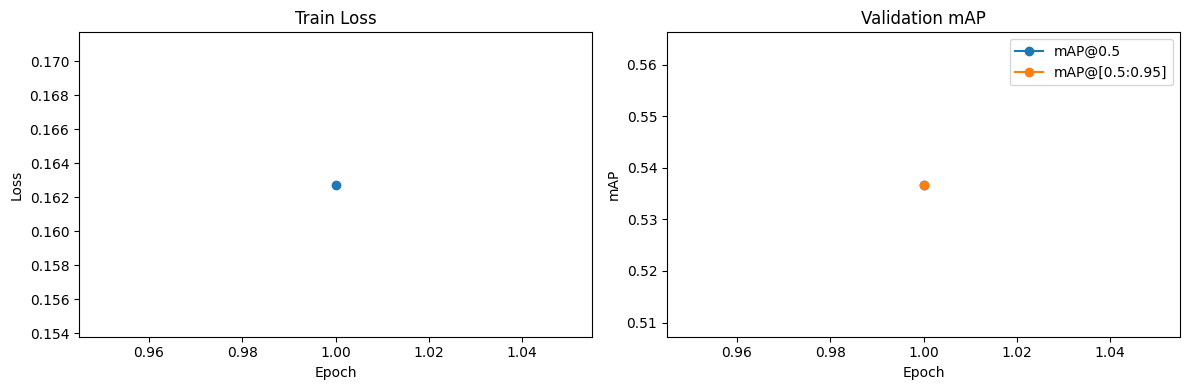

In [19]:
# Section 11 (continued): Plot metric trends
if len(history_df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o')
    axes[0].set_title('Train Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')

    axes[1].plot(history_df['epoch'], history_df['val_map_50'], marker='o', label='mAP@0.5')
    axes[1].plot(history_df['epoch'], history_df['val_map'], marker='o', label='mAP@[0.5:0.95]')
    axes[1].set_title('Validation mAP')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('mAP')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

In [20]:
# Section 12: Forgery-focused temporal post-processing

def infer_frame_scores(model, loader, device):
    model.eval()
    rows = []
    with torch.no_grad():
        for images, targets in tqdm(loader, desc='Frame inference', leave=False):
            images_dev = [img.to(device) for img in images]
            outputs = model(images_dev)
            for out, tgt in zip(outputs, targets):
                scores = out['scores'].detach().cpu().numpy()
                labels = out['labels'].detach().cpu().numpy() if len(out['labels']) else np.array([])
                fake_scores = scores[labels == 1] if len(scores) else np.array([])
                best_score = float(fake_scores.max()) if len(fake_scores) else 0.0
                rows.append({
                    'video_id': tgt['video_id'],
                    'timestamp_sec': float(tgt['timestamp_sec']),
                    'frame_forgery_score': best_score
                })
    return pd.DataFrame(rows)


def temporal_smooth_scores(df: pd.DataFrame, window: int):
    out = []
    for vid, g in df.groupby('video_id'):
        g = g.sort_values('timestamp_sec').copy()
        g['smoothed_score'] = g['frame_forgery_score'].rolling(window=window, min_periods=1, center=True).mean()
        out.append(g)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


def build_video_flags(smoothed_df: pd.DataFrame, threshold: float):
    if smoothed_df.empty:
        return pd.DataFrame(columns=['video_id', 'max_smoothed_score', 'mean_smoothed_score', 'forgery_flag'])
    agg = smoothed_df.groupby('video_id').agg(
        max_smoothed_score=('smoothed_score', 'max'),
        mean_smoothed_score=('smoothed_score', 'mean')
    ).reset_index()
    agg['forgery_flag'] = (agg['max_smoothed_score'] >= threshold).astype(int)
    return agg

Loaded best checkpoint from epoch 1


c:\Users\pujit\OneDrive\Desktop\major project\sudha\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pujit\OneDrive\Desktop\major project\sudha\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pujit\OneDrive\Desktop\major project\sudha\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

              precision    recall  f1-score   support

           0     0.5000    1.0000    0.6667         8
           1     0.0000    0.0000    0.0000         8

    accuracy                         0.5000        16
   macro avg     0.2500    0.5000    0.3333        16
weighted avg     0.2500    0.5000    0.3333        16



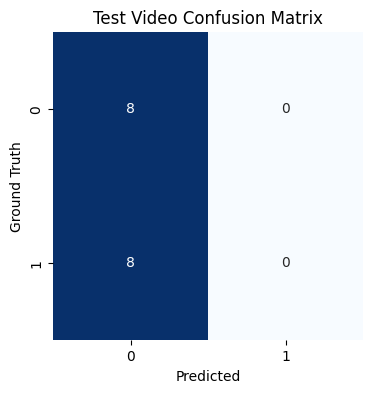

Saved outputs to: c:\Users\pujit\OneDrive\Desktop\major project\sudha\SDFVD\SDFVD\artifacts\outputs


,video_id,gt_label,max_smoothed_score,mean_smoothed_score,forgery_flag
0,v44,0,0.326145,0.326145,0
1,v26,0,0.000000,0.000000,0
2,v46,0,0.413548,0.413548,0
3,vs27,1,0.343474,0.343474,0
4,vs40,1,0.366594,0.366594,0


In [21]:
# Section 14: Evaluate on test videos and export predictions
if best_ckpt_path.exists():
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    print('Loaded best checkpoint from epoch', ckpt['epoch'])

frame_scores_df = infer_frame_scores(model, test_loader, DEVICE)
smoothed_test_df = temporal_smooth_scores(frame_scores_df, CONFIG['temporal_smoothing_window'])
video_pred_df = build_video_flags(smoothed_test_df, CONFIG['temporal_forgery_threshold'])

# Build ground-truth at video level (0=real,1=fake)
video_gt = test_df[['video_id', 'label']].drop_duplicates().rename(columns={'label': 'gt_label'})
video_eval_df = video_gt.merge(video_pred_df, on='video_id', how='left')
video_eval_df['max_smoothed_score'] = video_eval_df['max_smoothed_score'].fillna(0.0)
video_eval_df['mean_smoothed_score'] = video_eval_df['mean_smoothed_score'].fillna(0.0)
video_eval_df['forgery_flag'] = video_eval_df['forgery_flag'].fillna(0).astype(int)

print(classification_report(video_eval_df['gt_label'], video_eval_df['forgery_flag'], digits=4))
cm = confusion_matrix(video_eval_df['gt_label'], video_eval_df['forgery_flag'])
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Ground Truth')
plt.title('Test Video Confusion Matrix')
plt.show()

# Export predictions
video_eval_df.to_csv(OUTPUT_DIR / 'test_video_predictions.csv', index=False)
video_eval_df.to_json(OUTPUT_DIR / 'test_video_predictions.json', orient='records', indent=2)
smoothed_test_df.to_csv(OUTPUT_DIR / 'test_frame_scores_smoothed.csv', index=False)

print('Saved outputs to:', OUTPUT_DIR)
video_eval_df.head()

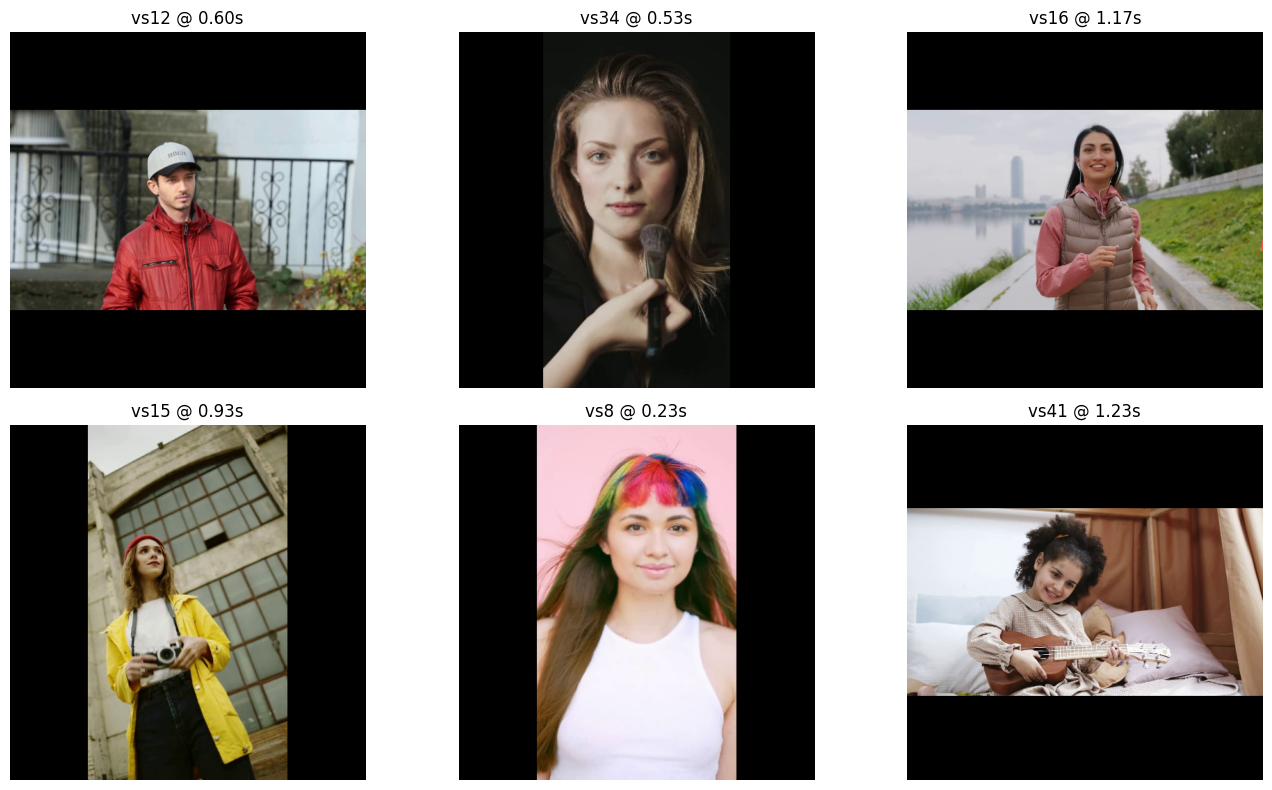

Failure cases: 8


,video_id,gt_label,max_smoothed_score,mean_smoothed_score,forgery_flag
3,vs27,1,0.343474,0.343474,0
4,vs40,1,0.366594,0.366594,0
7,vs12,1,0.329656,0.329656,0
8,vs8,1,0.329641,0.329641,0
9,vs15,1,0.313231,0.313231,0
10,vs16,1,0.413548,0.413548,0
11,vs34,1,0.327447,0.327447,0
15,vs41,1,0.327583,0.327583,0


In [22]:
# Section 15: Visualize detections and inspect failure cases

def draw_boxes_on_image(image_rgb, boxes, scores=None, labels=None, score_thr=0.3):
    img = image_rgb.copy()
    for i, box in enumerate(boxes):
        score = float(scores[i]) if scores is not None and i < len(scores) else 1.0
        label = int(labels[i]) if labels is not None and i < len(labels) else 1
        if score < score_thr:
            continue
        x1, y1, x2, y2 = map(int, box)
        color = (255, 80, 80) if label == 1 else (80, 255, 80)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, f'cls={label} s={score:.2f}', (x1, max(15, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return img

# Show a few sample predictions from the test set
model.eval()
num_show = min(6, len(test_ds))
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

with torch.no_grad():
    for i in range(num_show):
        img_t, tgt = test_ds[i]
        pred = model([img_t.to(DEVICE)])[0]
        img_np = (img_t.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
        vis = draw_boxes_on_image(
            img_np,
            pred['boxes'].detach().cpu().numpy(),
            pred['scores'].detach().cpu().numpy(),
            pred['labels'].detach().cpu().numpy(),
            score_thr=CONFIG['confidence_threshold']
        )
        axes[i].imshow(vis)
        axes[i].set_title(f"{tgt['video_id']} @ {tgt['timestamp_sec']:.2f}s")
        axes[i].axis('off')

for j in range(num_show, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Failure case table
if 'video_eval_df' in globals():
    failures = video_eval_df[video_eval_df['gt_label'] != video_eval_df['forgery_flag']].copy()
    print('Failure cases:', len(failures))
    display(failures.head(20))

## Notes

- This dataset appears to provide video-level labels only (`videos_real`, `videos_fake`).
- The notebook supports true detection annotations if you add YOLO/COCO labels under `annotations/`.
- Without box labels, it uses weak supervision: fake frames receive a full-frame pseudo-box.
- For stronger object detection quality, add frame-level forgery region annotations and retrain.